# SCF Mean-Field Examples

All supported SCF channels in one place.

- **Section 1**: Low-level Hartree-Fock — explicit builder construction + `scf_meanfield`
- **Section 2–5**: High-level `get_scf` for magnetic, CDW (distance and dense), s-wave, p-wave

In [1]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
include("../../src/TensorBinding.jl") # if you have the package installed, you can directly do using TensorBinding
using .TensorBinding

## 1. Low-level Hartree-Fock

Spinless chain with a long-range density-density interaction stored on the Hamiltonian
via `add_interaction!`. The Hartree and Fock builder closures are constructed from
the stored MPOs and passed to `scf_meanfield`.

In [2]:
L_hf   = 3
N_hf   = 2^L_hf
Nel_hf = div(N_hf, 2)

Vfun_hf(i, j) = i == j ? 0.0 :
    0.8 * exp(-abs(i - j) / 4.0) / sqrt((i - j)^2 + 0.7^2)

H_hf = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L_hf, boundary=:open, scale=4.0)
TensorBinding.add_interaction!(H_hf, Vfun_hf; channel=:hartree, maxbonddim=80)
TensorBinding.add_interaction!(H_hf, Vfun_hf; channel=:fock,    maxbonddim=80)
println(H_hf)

TBHamiltonian | L=3, N=8, scale=4.0, maxlinkdim=3 | geometry: 8 sites, 1D | no Tn cache


In [3]:
hartree_builder = TensorBinding.dense_hartree_builder(
    H_hf.interaction_mpo, L_hf, H_hf.sites; background=0.5, maxdim=100, cutoff=1e-8)

fock_builder = TensorBinding.fock_exchange_builder(
    H_hf.fock_mpo; sign=-1, maxdim=120, cutoff=1e-8)

rho0_hf = TensorBinding.get_mps(
    L_hf, H_hf.sites, n -> 0.5 + 0.04 * (-1)^n; type=Float64, tol=1e-10)

result_hf = TensorBinding.scf_meanfield(
    H_hf, hartree_builder;
    fock_builder=fock_builder,
    initial_density=rho0_hf,
    density_method=:mcweeny,
    Nel=Nel_hf,
    scale=4.5,
    max_scf_iter=30,
    scf_tol=1e-5,
    mix=0.65,
    maxdim=120,
    cutoff=1e-8,
    purif_maxiter=35,
    purif_tol=1e-6,
    verbose=true,
)
println("HF converged=$(result_hf.converged)  iter=$(result_hf.iterations)  rms=$(result_hf.rms_error)")

┌ Warning: Calling `inner(x::MPS, A::MPO, y::MPS)` where the site indices of the `MPS`
│ `x` and the `MPS` resulting from contracting `MPO` `A` with `MPS` `y` don't
│ match is deprecated as of ITensors v0.3 and will result in an error in ITensors
│ v0.4. The most common cause of this is something like the following:
│ 
│ ```julia
│ s = siteinds("S=1/2")
│ psi = random_mps(s)
│ H = MPO(s, "Id")
│ inner(psi, H, psi)
│ ```
│ 
│ `psi` has the Index structure `-s-(psi)` and `H` has the Index structure
│ `-s'-(H)-s-`, so the Index structure of would be `(dag(psi)-s- -s'-(H)-s-(psi)`
│  unless the prime levels were fixed. Previously we tried fixing the prime level
│   in situations like this, but we will no longer be doing that going forward.
│ 
│ There are a few ways to fix this. You can simply change:
│ 
│ ```julia
│ inner(psi, H, psi)
│ ```
│ 
│ to:
│ 
│ ```julia
│ inner(psi', H, psi)
│ ```
│ 
│ in which case the Index structure will be `(dag(psi)-s'-(H)-s-(psi)`.
│ 
│ Alternatively, you c

SCF iter=1 rms=0.02477554406201012 particle_err=1.1015899272770469e-6
SCF iter=2 rms=0.016453016652702757 particle_err=1.6668391120688852e-6
SCF iter=3 rms=0.00929792415375276 particle_err=3.570989490775389e-7
SCF iter=4 rms=0.005177248271107064 particle_err=9.252795685199544e-7
SCF iter=5 rms=0.0028419550910203854 particle_err=1.5283652308184514e-6
SCF iter=6 rms=0.0015511880522565257 particle_err=9.618687122348035e-7
SCF iter=7 rms=0.0008757497481244528 particle_err=3.8087941600650765e-7
SCF iter=8 rms=0.0005501136903322164 particle_err=1.049793502350127e-6
SCF iter=9 rms=0.0002558260524640836 particle_err=6.249662583002191e-7
SCF iter=10 rms=0.00012804794334299313 particle_err=1.5704440179398205e-6
SCF iter=11 rms=8.375113431553658e-5 particle_err=6.246699233436459e-7
SCF iter=12 rms=0.00011556982406773067 particle_err=3.116964633065322e-7
SCF iter=13 rms=0.00010756382819484068 particle_err=3.358820244159233e-7
SCF iter=14 rms=3.613712729401515e-5 particle_err=3.240396164727599e-7
S

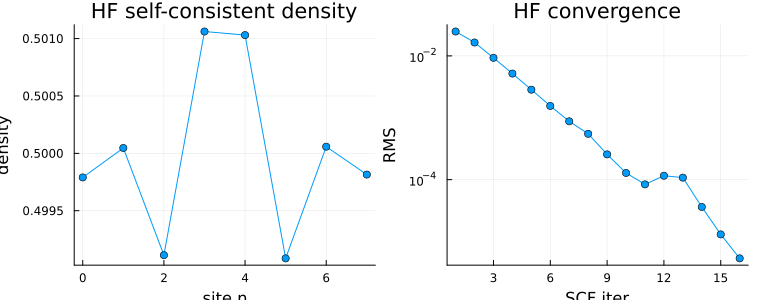

In [4]:
rho_hf = [TensorBinding.eval_mps(result_hf.density_mps, n) for n in 0:N_hf-1]
errs_hf = [h.rms_error for h in result_hf.history]

p1 = plot(0:N_hf-1, rho_hf; marker=:circle, xlabel="site n", ylabel="density",
          title="HF self-consistent density", legend=false)
p2 = plot(1:length(errs_hf), errs_hf; yscale=:log10, marker=:circle,
          xlabel="SCF iter", ylabel="RMS", title="HF convergence", legend=false)
plot(p1, p2; layout=(1, 2), size=(760, 300))

## 2. Magnetic Hubbard

On-site Hubbard coupling stored as `U · Identity` via `add_interaction!`. The
no-U `get_scf` dispatch reads from `H.interaction_mpo`.

In [5]:
U_mag = 2.0

H_mag = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=4, scale=3.5)
TensorBinding.add_spin!(H_mag)
TensorBinding.add_interaction!(H_mag, U_mag)
println(H_mag)

TBHamiltonian | L=4, N=16 +spin, scale=auto, maxlinkdim=3 | geometry: 16 sites, 1D | no Tn cache


In [6]:
result_mag = TensorBinding.get_scf(
    H_mag, :magnetic;
    density_method=:mcweeny,
    Nel_up=H_mag.N ÷ 2,
    Nel_dn=H_mag.N ÷ 2,
    background=0.5,
    scale=4.5,
    maxiters=56,
    purif_maxiter=30,
    purif_tol=1e-5,
    tol=1e-3,
    mixing=0.25,
    maxdim=90,
    cutoff=1e-8,
    verbose=true,
)
println("magnetic converged=$(result_mag.converged)  iter=$(result_mag.iterations)")

magnetic SCF iter=1 rms=0.02391878633255952 particle_err=4.363822742270429e-6
magnetic SCF iter=2 rms=0.023956551729578297 particle_err=4.59679530351309e-6
magnetic SCF iter=3 rms=0.024137131348184602 particle_err=3.8609798389543926e-6
magnetic SCF iter=4 rms=0.024280704809981037 particle_err=4.262272367050457e-6
magnetic SCF iter=5 rms=0.02449923719650356 particle_err=3.2607259683459233e-6
magnetic SCF iter=6 rms=0.0244516489627664 particle_err=4.935569875463841e-6
magnetic SCF iter=7 rms=0.02428879201348846 particle_err=3.5704375092038276e-6
magnetic SCF iter=8 rms=0.02397369691450074 particle_err=3.322718519882528e-6
magnetic SCF iter=9 rms=0.023470473806172256 particle_err=1.8736991274082015e-6
magnetic SCF iter=10 rms=0.02282052563923443 particle_err=1.3330622952167914e-6
magnetic SCF iter=11 rms=0.021983998823869026 particle_err=6.247258637515074e-6
magnetic SCF iter=12 rms=0.021168830996688825 particle_err=5.765705452631664e-6
magnetic SCF iter=13 rms=0.02022863945831356 particl

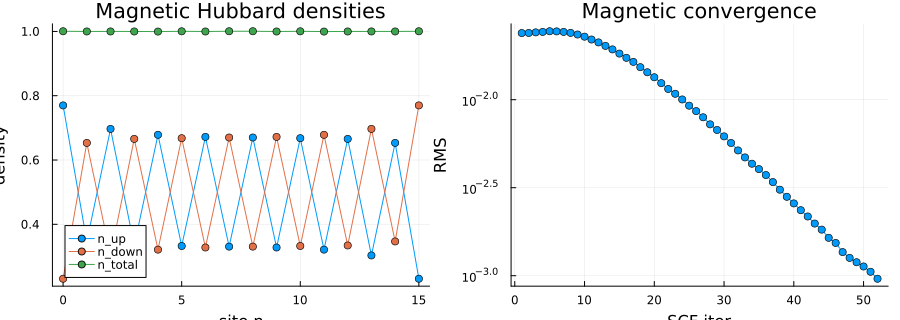

In [7]:
N_mag    = H_mag.N
rho_up   = [TensorBinding.eval_mps(result_mag.rho_up, n) for n in 0:N_mag-1]
rho_dn   = [TensorBinding.eval_mps(result_mag.rho_dn, n) for n in 0:N_mag-1]
errs_mag = [h.rms_error for h in result_mag.history]

p1 = plot(0:N_mag-1, [rho_up rho_dn rho_up .+ rho_dn];
          label=["n_up" "n_down" "n_total"], marker=:circle,
          xlabel="site n", ylabel="density", title="Magnetic Hubbard densities")
p2 = plot(1:length(errs_mag), errs_mag; yscale=:log10, marker=:circle,
          xlabel="SCF iter", ylabel="RMS", title="Magnetic convergence", legend=false)
plot(p1, p2; layout=(1, 2), size=(900, 320))

## 3. CDW

Two variants of the density-density interaction stored via `add_interaction!`:
a sparse nearest-neighbor MPO and a dense screened Coulomb kernel.

In [8]:
L_cdw   = 4
N_cdw   = 2^L_cdw
Nel_cdw = div(N_cdw, 2)

# base Hamiltonian — both variants share its site indices
H_cdw_base = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L_cdw, scale=4.0)
rho0_cdw   = TensorBinding.get_mps(
    H_cdw_base.L, H_cdw_base.sites, n -> 0.5 + 0.04 * (-1)^n; type=Float64, tol=1e-10)

# --- nearest-neighbor (deepcopy preserves site Index IDs) ---
H_nn     = deepcopy(H_cdw_base)
V_nn_mpo = TensorBinding.pair_distance_interaction_mpo(
    H_nn.L, H_nn.sites, 1, 3.0; maxdim=80, cutoff=1e-8)
TensorBinding.add_interaction!(H_nn, V_nn_mpo)

# --- dense long-range ---
V_long(i, j) = i == j ? 0.0 :
    2.0 * exp(-abs(i - j) / 3.0) / sqrt((i - j)^2 + 0.7^2)

H_long = deepcopy(H_cdw_base)
TensorBinding.add_interaction!(H_long, V_long)

TBHamiltonian | L=4, N=16, scale=4.0, maxlinkdim=3 | geometry: 16 sites, 1D | no Tn cache

In [9]:
result_nn = TensorBinding.get_scf(
    H_nn, :cdw;
    interaction=:dense,
    background=0.5,
    initial_density=rho0_cdw,
    density_method=:mcweeny,
    Nel=Nel_cdw,
    scale=5.0,
    maxiters=35,
    purif_maxiter=30,
    purif_tol=1e-5,
    tol=1e-3,
    mixing=0.45,
    maxdim=80,
    cutoff=1e-8,
    verbose=true,
)
println("NN CDW converged=$(result_nn.converged)  iter=$(result_nn.iterations)")

SCF iter=1 rms=0.09232443301625282 particle_err=6.465140920397516e-7
SCF iter=2 rms=0.12900361959836898 particle_err=9.059920405007915e-7
SCF iter=3 rms=0.15000901370746747 particle_err=3.0047047765435764e-6
SCF iter=4 rms=0.14383443865465215 particle_err=3.0140100859554764e-6
SCF iter=5 rms=0.1185374188240019 particle_err=1.7243956937917915e-6
SCF iter=6 rms=0.08818962372492371 particle_err=1.1838100215655345e-6
SCF iter=7 rms=0.061672951522926636 particle_err=1.928132067341437e-6
SCF iter=8 rms=0.04161104326123272 particle_err=1.0065615638765735e-6
SCF iter=9 rms=0.027542296306820792 particle_err=1.2176754058401684e-6
SCF iter=10 rms=0.017959625428057076 particle_err=1.6020318946985412e-6
SCF iter=11 rms=0.01163437439302749 particle_err=2.3769564876374716e-6
SCF iter=12 rms=0.007461082381788843 particle_err=1.9611018418075332e-6
SCF iter=13 rms=0.00482343908283564 particle_err=5.497041248858636e-7
SCF iter=14 rms=0.00313386432442917 particle_err=3.3710390034968896e-7
SCF iter=15 rms=

In [10]:
result_long = TensorBinding.get_scf(
    H_long, :cdw;
    interaction=:dense,
    background=0.5,
    initial_density=rho0_cdw,
    density_method=:mcweeny,
    Nel=Nel_cdw,
    scale=5.5,
    maxiters=40,
    purif_maxiter=30,
    purif_tol=1e-5,
    tol=1e-3,
    mixing=0.25,
    maxdim=90,
    cutoff=1e-8,
    verbose=true,
)
println("long-range CDW converged=$(result_long.converged)  iter=$(result_long.iterations)")

SCF iter=1 rms=0.010520972741887449 particle_err=1.942851834968451e-7
SCF iter=2 rms=0.006967231577536044 particle_err=1.134059099072715e-6
SCF iter=3 rms=0.004606423737089063 particle_err=1.106026452646347e-6
SCF iter=4 rms=0.003073992127205102 particle_err=2.126661271084629e-6
SCF iter=5 rms=0.002105389863296446 particle_err=6.891701920253013e-7
SCF iter=6 rms=0.0015442124943947529 particle_err=2.713697496936618e-6
SCF iter=7 rms=0.001242684043709312 particle_err=1.0695410050942655e-6
SCF iter=8 rms=0.0010725826263227117 particle_err=6.758333030987274e-7
SCF iter=9 rms=0.0010714586880541013 particle_err=3.49458503023925e-7
SCF iter=10 rms=0.0010399477776123728 particle_err=9.315545277388537e-7
SCF iter=11 rms=0.001101723960729269 particle_err=2.4196407872878467e-6
SCF iter=12 rms=0.0011160204842050375 particle_err=1.2054315732257237e-6
SCF iter=13 rms=0.0011942277798243082 particle_err=3.6789232815692685e-7
SCF iter=14 rms=0.0011264191729136418 particle_err=2.0312398234523243e-6
SCF 

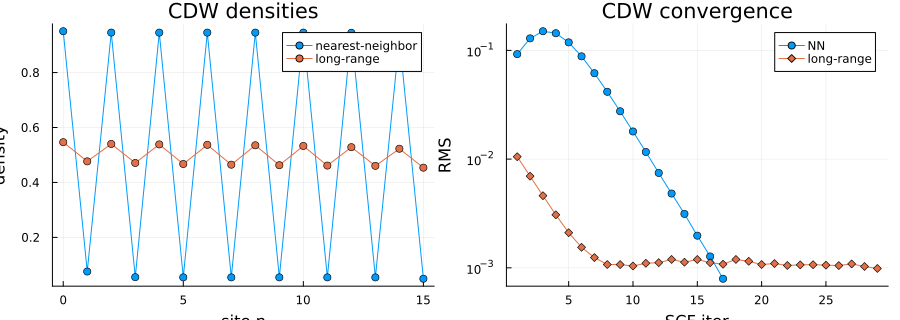

In [11]:
rho_nn   = [TensorBinding.eval_mps(result_nn.density_mps, n)   for n in 0:N_cdw-1]
rho_long = [TensorBinding.eval_mps(result_long.density_mps, n) for n in 0:N_cdw-1]
errs_nn   = [h.rms_error for h in result_nn.history]
errs_long = [h.rms_error for h in result_long.history]

p1 = plot(0:N_cdw-1, [rho_nn rho_long]; marker=:circle,
          label=["nearest-neighbor" "long-range"],
          xlabel="site n", ylabel="density", title="CDW densities")
p2 = plot(1:length(errs_nn), errs_nn; yscale=:log10, marker=:circle,
          label="NN", xlabel="SCF iter", ylabel="RMS", title="CDW convergence")
plot!(p2, 1:length(errs_long), errs_long; marker=:diamond, label="long-range")
plot(p1, p2; layout=(1, 2), size=(900, 320))

## 4. s-wave superconductor — `get_scf(H0, U, :swave)`

Attractive on-site Hubbard with spin-singlet pairing. The BdG Hamiltonian is rebuilt
at each iteration from the current pairing and Hartree profiles.

In [12]:
L_sw = 3
H_sw = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L_sw, scale=4.0)
TensorBinding.add_spin!(H_sw)
println(H_sw)

TBHamiltonian | L=3, N=8 +spin, scale=auto, maxlinkdim=3 | geometry: 8 sites, 1D | no Tn cache


In [13]:
U_sw = 3

result_sw = TensorBinding.get_scf(
    H_sw, U_sw, :swave;
    initial_delta=0.15,
    background=0.5,
    mu=0.0,
    density_method=:mcweeny,
    scale=4.8,
    maxiters=35,
    purif_maxiter=30,
    purif_tol=1e-5,
    tol=1e-3,
    mixing=0.8,
    maxdim=90,
    cutoff=1e-8,
    verbose=true,
)
println("s-wave converged=$(result_sw.converged)  iter=$(result_sw.iterations)")

s-wave SCF iter=1 rms=0.07878452738369313
s-wave SCF iter=2 rms=0.10691089847399689
s-wave SCF iter=3 rms=0.11640503809885265
s-wave SCF iter=4 rms=0.10267888596663546
s-wave SCF iter=5 rms=0.07802138798537868
s-wave SCF iter=6 rms=0.05380885796155734
s-wave SCF iter=7 rms=0.03462881045860454
s-wave SCF iter=8 rms=0.02119552793383449
s-wave SCF iter=9 rms=0.012881059758641636
s-wave SCF iter=10 rms=0.007781082903354763
s-wave SCF iter=11 rms=0.0044602138395097215
s-wave SCF iter=12 rms=0.0026910255412069604
s-wave SCF iter=13 rms=0.0015770191787213936
s-wave SCF iter=14 rms=0.000836863912907552
s-wave converged=true  iter=14


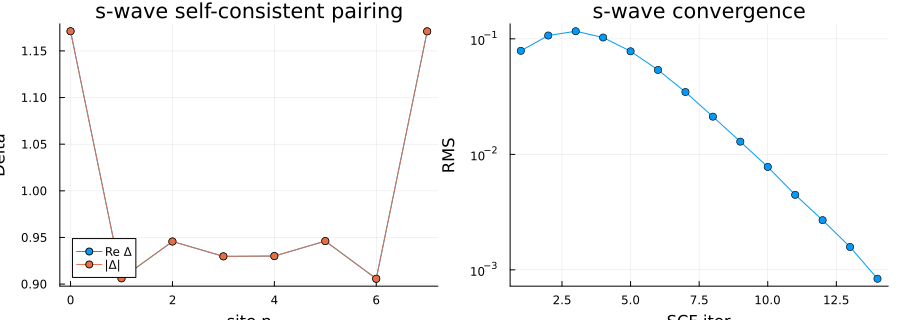

In [14]:
N_sw = H_sw.N
Delta_sw = [TensorBinding.eval_mps(result_sw.delta_mps, n)     for n in 0:N_sw-1]
F_sw     = [TensorBinding.eval_mps(result_sw.anomalous_mps, n) for n in 0:N_sw-1]
errs_sw  = [h.rms_error for h in result_sw.history]

p1 = plot(0:N_sw-1, [real.(Delta_sw) abs.(Delta_sw)]; marker=:circle,
          label=["Re Δ" "|Δ|"], xlabel="site n", ylabel="Delta",
          title="s-wave self-consistent pairing")
p2 = plot(1:length(errs_sw), errs_sw; yscale=:log10, marker=:circle,
          xlabel="SCF iter", ylabel="RMS", title="s-wave convergence", legend=false)
plot(p1, p2; layout=(1, 2), size=(900, 320))

## 5. p-wave equal-spin — `get_scf(H0, V, :pwave)`

Spinful nearest-neighbor equal-spin triplet pairing. `eta_down=-1` starts the two
equal-spin channels with opposite sign (helical seed).

In [15]:
L_pw = 3
H_pw = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L_pw, scale=4.0)
TensorBinding.add_spin!(H_pw)
println(H_pw)

TBHamiltonian | L=3, N=8 +spin, scale=auto, maxlinkdim=3 | geometry: 8 sites, 1D | no Tn cache


In [16]:
V_pw = 3.2

result_pw = TensorBinding.get_scf(
    H_pw, V_pw, :pwave;
    initial_up=0.12,
    eta_down=-1.0,
    distance=1,
    pairing_sign=-1.0,
    mu=0.0,
    density_method=:mcweeny,
    scale=6.0,
    maxiters=65,
    purif_maxiter=30,
    purif_tol=1e-5,
    tol=1e-3,
    mixing=0.75,
    maxdim=100,
    cutoff=1e-8,
    verbose=true,
)
println("p-wave converged=$(result_pw.converged)  iter=$(result_pw.iterations)")

p-wave equal-spin SCF iter=1 rms=0.06315404067016782
p-wave equal-spin SCF iter=2 rms=0.05408614767468923
p-wave equal-spin SCF iter=3 rms=0.06477735384199428
p-wave equal-spin SCF iter=4 rms=0.07632250804090998
p-wave equal-spin SCF iter=5 rms=0.08547366084291608
p-wave equal-spin SCF iter=6 rms=0.08773680817101553
p-wave equal-spin SCF iter=7 rms=0.0818712875660188
p-wave equal-spin SCF iter=8 rms=0.06866812018685489
p-wave equal-spin SCF iter=9 rms=0.052610511645763657
p-wave equal-spin SCF iter=10 rms=0.037882038531261805
p-wave equal-spin SCF iter=11 rms=0.02509593320782652
p-wave equal-spin SCF iter=12 rms=0.017546334167179913
p-wave equal-spin SCF iter=13 rms=0.011509097835962302
p-wave equal-spin SCF iter=14 rms=0.007325015616985576
p-wave equal-spin SCF iter=15 rms=0.004728036255419725
p-wave equal-spin SCF iter=16 rms=0.0030910107849810445
p-wave equal-spin SCF iter=17 rms=0.0027820738100819554
p-wave equal-spin SCF iter=18 rms=0.0019782224309558318
p-wave equal-spin SCF iter

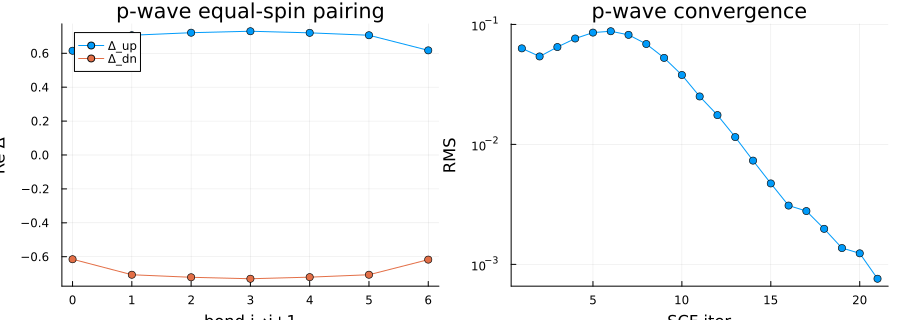

In [17]:
N_pw = H_pw.N
bond_sites = 0:N_pw-2
Delta_up_pw = [TensorBinding.eval_mps(result_pw.delta_up_mps, n) for n in bond_sites]
Delta_dn_pw = [TensorBinding.eval_mps(result_pw.delta_dn_mps, n) for n in bond_sites]
errs_pw     = [h.rms_error for h in result_pw.history]

p1 = plot(bond_sites, [real.(Delta_up_pw) real.(Delta_dn_pw)]; marker=:circle,
          label=["Δ_up" "Δ_dn"], xlabel="bond i→i+1", ylabel="Re Δ",
          title="p-wave equal-spin pairing")
p2 = plot(1:length(errs_pw), errs_pw; yscale=:log10, marker=:circle,
          xlabel="SCF iter", ylabel="RMS", title="p-wave convergence", legend=false)
plot(p1, p2; layout=(1, 2), size=(900, 320))